---
## dl01.ipynb
---


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## One Perceptron

In [ ]:
class Sn:
    def __init__(self, rate = 0.015, iterations = 1000):
        self.rate = rate
        self.iterations = iterations
        self.weights = None

    def _sigmoid(self,z):
        return 1/(1+np.exp(-z))

    def _log_loss(self, y, p):
        epsilon = 1e-15
        p_adj = np.clip(p,epsilon, 1-epsilon)
        loss = -np.mean(y*np.log(p_adj) + (1-y)*np.log(1-p_adj))
        return loss

    def fit(self, X, y):

        rows, cols = X.shape
        
        #initialize the weights
        self.weights = np.random.normal(loc = 0, scale = 0.015, size = cols+1)

        #Augmenting X with column of ones at the extreme left
        X_aug = np.hstack((np.ones((rows,1)),X))

        #Gradient Descent
        for i in range(self.iterations):

            #linear model
            z = np.dot(X_aug, self.weights)
            p = self._sigmoid(z)

            if i%100 == 0: print(self._log_loss(y, p))
            
            #Compute Gradient
            dw = (1/rows)*np.dot(X_aug.T, p - y)

            #update weights
            self.weights = self.weights - self.rate * dw

    def predict_proba(self, X):
        X_aug = np.hstack((np.ones((X.shape[0], 1)), X))
        model = np.dot(X_aug, self.weights)
        return self._sigmoid(model)
        
    def predict(self, X):
        threshold = 0.5
        y_hat = self.predict_proba(X)
        y_zero_one = [1 if i>=threshold else 0 for i in y_hat]
        return np.array(y_zero_one)
        

## Importing the dataset

In [ ]:
dataset = pd.read_csv('Age_Salary_Buy.csv')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

## Splitting the dataset into the Training set and Test set

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

## Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

# Compute the means and standard deviations of features w.r.t
# training set. Transform X_train
X_train = sc.fit_transform(X_train)

# Using the scaler computed above, transform X_test
X_test = sc.transform(X_test)

## Training the Simple Network model on the Training set

In [ ]:
classifier = Sn(rate = 0.05, iterations = 10000)
classifier.fit(X_train, y_train)

0.6916573612620599
0.4511484626015267
0.40721062428906984
0.39102426911449933
0.383297556619387
0.3790924051912634
0.3766166644080331
0.3750814634198497
0.3740941451509178
0.3734419733269343
0.3730023728556737
0.37270137059870345
0.37249269907451416
0.3723465929752865
0.37224346700246674
0.3721701969318332
0.37211785595493646
0.37208029713431245
0.37205324433894865
0.3720336974587439
0.3720195365836996
0.37200925476449515
0.3720017753548331
0.3719963258493798
0.37199234995894903
0.37198944586236804
0.37198732255618466
0.3719857688238782
0.37198463106964036
0.3719837974188294
0.37198318627295535
0.3719827380461213
0.3719824091829827
0.37198216781862553
0.37198199062366105
0.37198186050709875
0.3719817649414221
0.3719816947398583
0.3719816431628328
0.3719816052644055
0.3719815774138708
0.3719815569453453
0.3719815419009609
0.3719815308425643
0.3719815227135949
0.37198151673773
0.3719815123444908
0.3719815091146205
0.37198150673997316
0.37198150499405047
0.3719815037103578
0.3719815027665

## Predicting the Training Set Results

In [ ]:
y_pred = classifier.predict(X_train)

## Making the Confusion Matrix for the Training Set

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_train, y_pred)
print(cm)
print(accuracy_score(y_train, y_pred))

[[171  18]
 [ 36  75]]
0.82


## Predicting the Test set results

In [ ]:
y_pred_test = classifier.predict(X_test)

## Making the Confusion Matrix for the Test Set

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm_test = confusion_matrix(y_test, y_pred_test)
print(cm_test)
print(accuracy_score(y_test, y_pred_test))

[[65  3]
 [ 8 24]]
0.89


## Applying Logistic Regression on the same Data

In [ ]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state = 0)
classifier.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,0
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [ ]:
y1_pred = classifier.predict(X_test)

In [ ]:
cm1 = confusion_matrix(y_test, y1_pred)
print(cm1)
accuracy_score(y_test, y1_pred)

[[65  3]
 [ 8 24]]


0.89

## Visualising the Training set results

C:\Users\omar\AppData\Local\Temp\ipykernel_5368\3592760932.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)


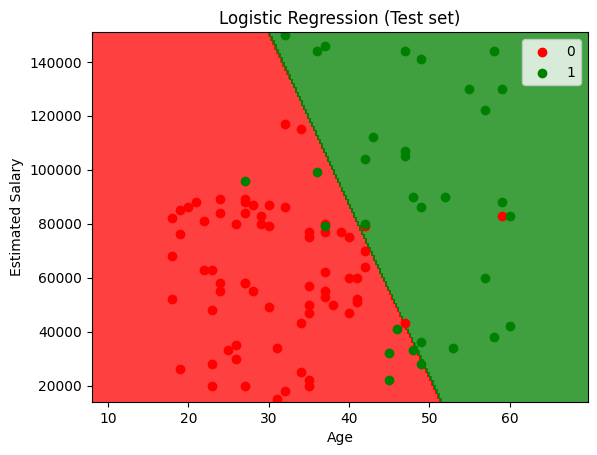

In [ ]:
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(X_test), y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 0.25),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 0.25))
plt.contourf(X1, X2, classif.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('Logistic Regression (Test set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

---
## dl02.ipynb
---


In [ ]:
import numpy as np
import pandas as pdb
import matplotlib.pyplot as plt

In [ ]:

class Value:
    """ stores a single scalar value and its gradient """

    def __init__(self, data, _children=()):
        self.data = data
        self.grad = 0
        
        self._backward = lambda: None
        self._prev = set(_children)        

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other))

        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward

        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other))

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers"
        out = Value(self.data**other, (self,))

        def _backward():
            self.grad += (other * self.data**(other-1)) * out.grad
        out._backward = _backward

        return out

    def relu(self):
        out = Value(0 if self.data < 0 else self.data, (self,))

        def _backward():
            self.grad += (out.data > 0) * out.grad
        out._backward = _backward

        return out

    def tanh(self):
        out = Value(np.tanh(self.data), (self,))

        def _backward():
            self.grad += (1-out.data**2) * out.grad
        out._backward = _backward

        return out

    def backward(self):

        # topological order all of the children in the graph
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        # go one variable at a time and apply the chain rule to get its gradient
        self.grad = 1
        for v in reversed(topo):
            v._backward()

    def __neg__(self): # -self
        return self * -1

    def __radd__(self, other): # other + self
        return self + other

    def __sub__(self, other): # self - other
        return self + (-other)

    def __rsub__(self, other): # other - self
        return other + (-self)

    def __rmul__(self, other): # other * self
        return self * other

    def __truediv__(self, other): # self / other
        return self * other**-1

    def __rtruediv__(self, other): # other / self
        return other * self**-1

    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"


In [ ]:
import random
class Neuron:

    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(0)        

    def __call__(self, x):
        act = sum((wi*xi for wi,xi in zip(self.w, x)), self.b)
        return act.tanh()

    def parameters(self):
        return self.w + [self.b]

    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0
    
    def __repr__(self):
        return f"Linear Neuron({len(self.w)})"

class Layer:

    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        out = [n(x) for n in self.neurons]
        return out[0] if len(out) == 1 else out

    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]

    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0
    
    def __repr__(self):
        return f"Layer"

class MLP:

    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0
    
    def __repr__(self):
        return f"MLP"

In [ ]:
mlp = MLP(3,[4,4,1])
etha = 0.05
print(len(mlp.parameters()))

41


In [ ]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
    ]
ys = [1.0, -1.0, -1.0, 1.0]

In [ ]:
for k in range(1000):

    # Forward pass
    ypred = [mlp(x) for x in xs]    
    loss = sum((yout-ygt)**2 for ygt, yout in zip(ys, ypred))/len(ypred)

    # Bacward pass
    mlp.zero_grad()
    loss.backward()

    # Update
    for p in mlp.parameters():
        p.data += -etha*p.grad

    if k%10 == 0:print(k, loss.data)
    

0 0.0001232444688301744
10 0.00012291635495817176
20 0.00012258991863288158
30 0.00012226514718787315
40 0.0001219420280832043
50 0.00012162054890384488
60 0.00012130069735813258
70 0.0001209824612762514
80 0.00012066582860872392
90 0.0001203507874249354
100 0.00012003732591168008
110 0.00011972543237171463
120 0.00011941509522235109
130 0.00011910630299406034
140 0.00011879904432909362
150 0.00011849330798013625
160 0.00011818908280896134
170 0.00011788635778512423
180 0.00011758512198466254
190 0.00011728536458881351
200 0.0001169870748827616
210 0.00011669024225439268
220 0.00011639485619307172
230 0.0001161009062884328
240 0.00011580838222919609
250 0.00011551727380198862
260 0.00011522757089019245
270 0.0001149392634728042
280 0.00011465234162331022
290 0.00011436679550857988
300 0.00011408261538777578
310 0.00011379979161127071
320 0.00011351831461959139
330 0.00011323817494236665
340 0.00011295936319729982
350 0.00011268187008914438
360 0.00011240568640870672
370 0.0001121308030

---
## dl03.ipynb
---


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
dataset = pd.read_csv('Age_Salary_Buy.csv')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

# Compute the means and standard deviations of features w.r.t
# training set. Transform X_train
X_train = sc.fit_transform(X_train)

# Using the scaler computed above, transform X_test
X_test = sc.transform(X_test)

In [ ]:
class Value:
    """ stores a single scalar value and its gradient """

    def __init__(self, data, _children=()):
        self.data = data
        self.grad = 0
        
        self._backward = lambda: None
        self._prev = set(_children)        

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other))

        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward

        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other))

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers"
        out = Value(self.data**other, (self,))

        def _backward():
            self.grad += (other * self.data**(other-1)) * out.grad
        out._backward = _backward

        return out

    def relu(self):
        out = Value(0 if self.data < 0 else self.data, (self,))

        def _backward():
            self.grad += (out.data > 0) * out.grad
        out._backward = _backward

        return out

    def tanh(self):
        out = Value(np.tanh(self.data), (self,))

        def _backward():
            self.grad += (1-out.data**2) * out.grad
        out._backward = _backward

        return out


    def log(self):
        eps = 1e-15
        x = np.clip(self.data, eps, 1 - eps)
        out = Value(np.log(x), (self,))
        def _backward():
            # derivative uses clamped x to avoid 1/0
            self.grad += (1/x) * out.grad
        out._backward = _backward
        return out


    def sig(self):
        out = Value(1.0/(1+np.exp(-self.data)), (self,))

        def _backward():
            self.grad += out.data*(1-out.data) * out.grad
        out._backward = _backward

        return out
    
    def backward(self):

        # topological order all of the children in the graph
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        # go one variable at a time and apply the chain rule to get its gradient
        self.grad = 1
        for v in reversed(topo):
            v._backward()

    def __neg__(self): # -self
        return self * -1

    def __radd__(self, other): # other + self
        return self + other

    def __sub__(self, other): # self - other
        return self + (-other)

    def __rsub__(self, other): # other - self
        return other + (-self)

    def __rmul__(self, other): # other * self
        return self * other

    def __truediv__(self, other): # self / other
        return self * other**-1

    def __rtruediv__(self, other): # other / self
        return other * self**-1

    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"


In [ ]:
import random

# Activation helpers that operate on a single Value
def act_identity(v): 
    return v

def act_relu(v):
    return v.relu()

def act_tanh(v):
    return v.tanh()

def act_sigmoid(v):
    return v.sig()

class Neuron:

    def __init__(self, nin, activation=act_sigmoid):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(0)        
        self.activation = activation

    def __call__(self, x):
        act = sum((wi*xi for wi,xi in zip(self.w, x)), self.b)
        return self.activation(act)

    def parameters(self):
        return self.w + [self.b]

    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0
    
    def __repr__(self):
        return f"Linear Neuron({len(self.w)})"

class Layer:

    def __init__(self, nin, nout, activation=act_sigmoid):
        self.neurons = [Neuron(nin, activation=activation) for _ in range(nout)]

    def __call__(self, x):
        out = [n(x) for n in self.neurons]
        return out[0] if len(out) == 1 else out

    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]

    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0
    
    def __repr__(self):
        return f"Layer"

class MLP:

    def __init__(self, nin, nouts, activations):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1], activation=activations[i]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0
    
    def __repr__(self):
        return f"MLP"

In [ ]:
    def log_loss(y, p):
        losses = [-pi.log()*yi - (-pi+1).log()*(1-yi) for pi, yi in zip(p,y)]
        loss = sum(losses)/len(losses)
        return loss

In [ ]:
mlp = MLP(2,[4,4,1],[act_relu,act_relu,act_sigmoid])
etha = 0.05
print(len(mlp.parameters()))

37


In [ ]:
batch_size=32
for k in range(100):    
    #ri = np.random.permutation(X_train.shape[0])[:batch_size]
    Xb, yb = X_train, y_train 
    #Xb, yb = X_train[ri], y_train[ri]    
    
    # Forward pass
    ypred = [mlp(x) for x in Xb]    
    loss = log_loss(yb, ypred)

    # Bacward pass
    mlp.zero_grad()
    loss.backward()

    # Update
    for p in mlp.parameters():
        p.data += -etha*p.grad

    if k%10 == 0: print(k, loss.data)

0 0.2674981421180223
10 0.26731675832454005
20 0.2671653339055735
30 0.2670266071648589
40 0.2668942805300363
50 0.26676701435358996
60 0.2666433947212399
70 0.2665248355656775
80 0.26641096760516103
90 0.26629777233411395


---
## dl04.ipynb
---


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
dataset = pd.read_csv('Age_Salary_Buy.csv')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values
print(dataset.iloc[:10, :])
X[:,1] = X[:,1]/1000
print(X[:10,:])

   Age  EstimatedSalary  Purchased
0   19            19000          0
1   35            20000          0
2   26            43000          0
3   27            57000          0
4   19            76000          0
5   27            58000          0
6   27            84000          0
7   32           150000          1
8   25            33000          0
9   35            65000          0
[[ 19  19]
 [ 35  20]
 [ 26  43]
 [ 27  57]
 [ 19  76]
 [ 27  58]
 [ 27  84]
 [ 32 150]
 [ 25  33]
 [ 35  65]]


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

In [ ]:
# Keep copies for plotting
X_train_orig = X_train.copy()
X_test_orig  = X_test.copy()

In [ ]:
print(X_train_orig[:10,:])

[[ 44  39]
 [ 32 120]
 [ 38  50]
 [ 32 135]
 [ 52  21]
 [ 53 104]
 [ 39  42]
 [ 38  61]
 [ 36  50]
 [ 36  63]]


In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

# Compute the means and standard deviations of features w.r.t
# training set. Transform X_train
X_train = sc.fit_transform(X_train)

# Using the scaler computed above, transform X_test
X_test = sc.transform(X_test)

In [ ]:
print(X_train[:10,:])

[[ 0.58164944 -0.88670699]
 [-0.60673761  1.46173768]
 [-0.01254409 -0.5677824 ]
 [-0.60673761  1.89663484]
 [ 1.37390747 -1.40858358]
 [ 1.47293972  0.99784738]
 [ 0.08648817 -0.79972756]
 [-0.01254409 -0.24885782]
 [-0.21060859 -0.5677824 ]
 [-0.21060859 -0.19087153]]


In [ ]:
class Value:
    """ stores a single scalar value and its gradient """

    def __init__(self, data, _children=()):
        self.data = data
        self.grad = 0
        
        self._backward = lambda: None
        self._prev = set(_children)        

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other))

        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward

        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other))

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers"
        out = Value(self.data**other, (self,))

        def _backward():
            self.grad += (other * self.data**(other-1)) * out.grad
        out._backward = _backward

        return out

    def relu(self):
        out = Value(0 if self.data < 0 else self.data, (self,))

        def _backward():
            self.grad += (out.data > 0) * out.grad
        out._backward = _backward

        return out

    def tanh(self):
        out = Value(np.tanh(self.data), (self,))

        def _backward():
            self.grad += (1-out.data**2) * out.grad
        out._backward = _backward

        return out


    def log(self):
        eps = 1e-15
        x = np.clip(self.data, eps, 1 - eps)
        out = Value(np.log(x), (self,))
        def _backward():
            # derivative uses clamped x to avoid 1/0
            self.grad += (1/x) * out.grad
        out._backward = _backward
        return out


    def sig(self):
        out = Value(1.0/(1+np.exp(-self.data)), (self,))

        def _backward():
            self.grad += out.data*(1-out.data) * out.grad
        out._backward = _backward

        return out
    
    def backward(self):

        # topological order all of the children in the graph
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        # go one variable at a time and apply the chain rule to get its gradient
        self.grad = 1
        for v in reversed(topo):
            v._backward()

    def __neg__(self): # -self
        return self * -1

    def __radd__(self, other): # other + self
        return self + other

    def __sub__(self, other): # self - other
        return self + (-other)

    def __rsub__(self, other): # other - self
        return other + (-self)

    def __rmul__(self, other): # other * self
        return self * other

    def __truediv__(self, other): # self / other
        return self * other**-1

    def __rtruediv__(self, other): # other / self
        return other * self**-1

    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"


In [ ]:
import random

# Activation helpers that operate on a single Value
def act_identity(v): 
    return v

def act_relu(v):
    return v.relu()

def act_tanh(v):
    return v.tanh()

def act_sigmoid(v):
    return v.sig()

class Neuron:

    def __init__(self, nin, activation=act_sigmoid):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(0)        
        self.activation = activation

    def __call__(self, x):
        act = sum((wi*xi for wi,xi in zip(self.w, x)), self.b)
        return self.activation(act)

    def parameters(self):
        return self.w + [self.b]

    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0
    
    def __repr__(self):
        return f"Linear Neuron({len(self.w)})"

class Layer:

    def __init__(self, nin, nout, activation=act_sigmoid):
        self.neurons = [Neuron(nin, activation=activation) for _ in range(nout)]

    def __call__(self, x):
        out = [n(x) for n in self.neurons]
        return out[0] if len(out) == 1 else out

    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]

    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0
    
    def __repr__(self):
        return f"Layer"

class MLP:

    def __init__(self, nin, nouts, activations):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1], activation=activations[i]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0
    
    def __repr__(self):
        return f"MLP"

In [ ]:
    def log_loss(y, p):
        losses = [-pi.log()*yi - (-pi+1).log()*(1-yi) for pi, yi in zip(p,y)]
        loss = sum(losses)/len(losses)
        return loss

In [ ]:
mlp = MLP(2,[4,1],[act_relu,act_sigmoid])
etha = 0.05
print(len(mlp.parameters()))

17


In [ ]:
batch_size = 32
n_samples = X_train.shape[0]

for epoch in range(500):
    # Shuffle data at the start of each epoch
    indices = np.random.permutation(n_samples)
    X_shuffled = X_train[indices]
    y_shuffled = y_train[indices]

    # Loop over batches
    for start in range(0, n_samples, batch_size):
        end = start + batch_size
        Xb = X_shuffled[start:end]
        yb = y_shuffled[start:end]

        # Forward pass
        ypred = [mlp(x) for x in Xb]
        loss = log_loss(yb, ypred)

        # Backward pass
        mlp.zero_grad()
        loss.backward()

        # Update
        for p in mlp.parameters():
            p.data -= etha * p.grad

    if epoch%10 == 0: print(epoch, loss.data)

0 0.45509789885940194
10 0.26175279044078587
20 0.15799458470698674
30 0.29456437731611623
40 0.4064542009863237
50 0.19920766611587096
60 0.4316004412902788
70 0.27262069241980835
80 0.33065718754189616
90 0.1795639229677453
100 0.0805015984300834
110 0.06322249773179767
120 0.06902288622543697
130 0.24881466937212648
140 0.27777250010519433
150 0.36720853136072784
160 0.09262695851344079
170 0.058146788429682274
180 0.059868824763880585
190 0.4171215035473235
200 0.3711658975012109
210 0.21972499124921643
220 0.34895209692564594
230 0.18291618358987574
240 0.4292462002539722
250 0.25681183541178765
260 0.13841151883486646
270 0.3635039929938782
280 0.44077661633671483
290 0.31148944491134034
300 0.21826660211823545
310 0.18143900530978918
320 0.14248590694388485
330 0.3760132375695331
340 0.24266944560774997
350 0.2725400981309749
360 0.40488287876222284
370 0.09359949667184148
380 0.2921282042396591
390 0.2404845485700941
400 0.20996222825606406
410 0.2483891554347866
420 0.17195989

In [ ]:
def predict_proba_mlp(model, X_scaled):
    """Return probabilities (numpy array) for X_scaled using micrograd MLP."""
    probs = []
    for x in X_scaled:
        out = model(x)                 # out is a Value
        probs.append(float(out.data))  # extract scalar
    return np.array(probs)

In [ ]:
def predict_mlp(model, X_scaled):
    yprob = predict_proba_mlp(model, X_scaled)
    y_zero_one = [1 if i>=0.5 else 0 for i in yprob]
    return np.array(y_zero_one)

In [ ]:
y_pred = predict_mlp(mlp, X_train)

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_train, y_pred)
print(cm)
print(accuracy_score(y_train, y_pred))

[[173  16]
 [ 13  98]]
0.9033333333333333


In [ ]:
y_pred_test = predict_mlp(mlp, X_test)

In [ ]:
cm = confusion_matrix(y_test, y_pred_test)
print(cm)
print(accuracy_score(y_test, y_pred_test))

[[64  4]
 [ 5 27]]
0.91


In [ ]:
print(X_train_orig[:10,:])

[[ 44  39]
 [ 32 120]
 [ 38  50]
 [ 32 135]
 [ 52  21]
 [ 53 104]
 [ 39  42]
 [ 38  61]
 [ 36  50]
 [ 36  63]]


In [ ]:
X_set= X_train_orig
#X_set[:,1] = X_set[:,1]/1000
print(X_set[0:10,:])

[[ 44  39]
 [ 32 120]
 [ 38  50]
 [ 32 135]
 [ 52  21]
 [ 53 104]
 [ 39  42]
 [ 38  61]
 [ 36  50]
 [ 36  63]]


(14.0, 150.75)

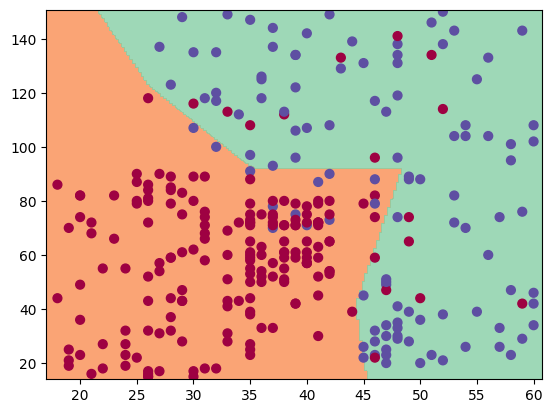

In [ ]:
h = 0.25
x_min, x_max = X_set[:, 0].min() - 1, X_set[:, 0].max() + 1
y_min, y_max = X_set[:, 1].min() - 1, X_set[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Xmesh = np.c_[xx.ravel(), yy.ravel()]
Xmesh = sc.transform(Xmesh)
inputs = [list(map(Value, xrow)) for xrow in Xmesh]
scores = list(map(mlp, inputs))
Z = np.array([s.data >= 0.5 for s in scores])
Z = Z.reshape(xx.shape)

fig = plt.figure()
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
plt.scatter(X_set[:, 0], X_set[:, 1], c=y_train, s=40, cmap=plt.cm.Spectral)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())

---
## dl05.ipynb
---


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
dataset = pd.read_csv('Age_Salary_Buy.csv')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values
print(dataset.iloc[:10, :])
X[:,1] = X[:,1]/1000
print(X[:10,:])

   Age  EstimatedSalary  Purchased
0   19            19000          0
1   35            20000          0
2   26            43000          0
3   27            57000          0
4   19            76000          0
5   27            58000          0
6   27            84000          0
7   32           150000          1
8   25            33000          0
9   35            65000          0
[[ 19  19]
 [ 35  20]
 [ 26  43]
 [ 27  57]
 [ 19  76]
 [ 27  58]
 [ 27  84]
 [ 32 150]
 [ 25  33]
 [ 35  65]]


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

In [ ]:
# Keep copies for plotting
X_train_orig = X_train.copy()
X_test_orig  = X_test.copy()

In [ ]:
print(X_train_orig[:10,:])

[[ 44  39]
 [ 32 120]
 [ 38  50]
 [ 32 135]
 [ 52  21]
 [ 53 104]
 [ 39  42]
 [ 38  61]
 [ 36  50]
 [ 36  63]]


In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

# Compute the means and standard deviations of features w.r.t
# training set. Transform X_train
X_train = sc.fit_transform(X_train)

# Using the scaler computed above, transform X_test
X_test = sc.transform(X_test)

In [ ]:
print(X_train[:10,:])

[[ 0.58164944 -0.88670699]
 [-0.60673761  1.46173768]
 [-0.01254409 -0.5677824 ]
 [-0.60673761  1.89663484]
 [ 1.37390747 -1.40858358]
 [ 1.47293972  0.99784738]
 [ 0.08648817 -0.79972756]
 [-0.01254409 -0.24885782]
 [-0.21060859 -0.5677824 ]
 [-0.21060859 -0.19087153]]


In [ ]:
class Value:
    """ stores a single scalar value and its gradient """

    def __init__(self, data, _children=()):
        self.data = data
        self.grad = 0
        
        self._backward = lambda: None
        self._prev = set(_children)        

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other))

        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward

        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other))

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers"
        out = Value(self.data**other, (self,))

        def _backward():
            self.grad += (other * self.data**(other-1)) * out.grad
        out._backward = _backward

        return out

    def relu(self):
        out = Value(0 if self.data < 0 else self.data, (self,))

        def _backward():
            self.grad += (out.data > 0) * out.grad
        out._backward = _backward

        return out

    def tanh(self):
        out = Value(np.tanh(self.data), (self,))

        def _backward():
            self.grad += (1-out.data**2) * out.grad
        out._backward = _backward

        return out


    def log(self):
        eps = 1e-15
        x = np.clip(self.data, eps, 1 - eps)
        out = Value(np.log(x), (self,))
        def _backward():
            # derivative uses clamped x to avoid 1/0
            self.grad += (1/x) * out.grad
        out._backward = _backward
        return out


    def sig(self):
        out = Value(1.0/(1+np.exp(-self.data)), (self,))

        def _backward():
            self.grad += out.data*(1-out.data) * out.grad
        out._backward = _backward

        return out
    
    def backward(self):

        # topological order all of the children in the graph
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        # go one variable at a time and apply the chain rule to get its gradient
        self.grad = 1
        for v in reversed(topo):
            v._backward()

    def __neg__(self): # -self
        return self * -1

    def __radd__(self, other): # other + self
        return self + other

    def __sub__(self, other): # self - other
        return self + (-other)

    def __rsub__(self, other): # other - self
        return other + (-self)

    def __rmul__(self, other): # other * self
        return self * other

    def __truediv__(self, other): # self / other
        return self * other**-1

    def __rtruediv__(self, other): # other / self
        return other * self**-1

    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"


In [ ]:
import random

# Activation helpers that operate on a single Value
def act_identity(v): 
    return v

def act_relu(v):
    return v.relu()

def act_tanh(v):
    return v.tanh()

def act_sigmoid(v):
    return v.sig()

class Neuron:

    def __init__(self, nin, activation=act_sigmoid):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(0)        
        self.activation = activation

    def __call__(self, x):
        act = sum((wi*xi for wi,xi in zip(self.w, x)), self.b)
        return self.activation(act)

    def parameters(self):
        return self.w + [self.b]

    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0
    
    def __repr__(self):
        return f"Linear Neuron({len(self.w)})"

class Layer:

    def __init__(self, nin, nout, activation=act_sigmoid):
        self.neurons = [Neuron(nin, activation=activation) for _ in range(nout)]

    def __call__(self, x):
        out = [n(x) for n in self.neurons]
        return out[0] if len(out) == 1 else out

    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]

    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0
    
    def __repr__(self):
        return f"Layer"

class MLP:

    def __init__(self, nin, nouts, activations):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1], activation=activations[i]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0
    
    def __repr__(self):
        return f"MLP"

In [ ]:
    def log_loss(y, p):
        losses = [-pi.log()*yi - (-pi+1).log()*(1-yi) for pi, yi in zip(p,y)]
        loss = sum(losses)/len(losses)
        return loss

In [ ]:
mlp = MLP(2,[4,1],[act_relu,act_sigmoid])
etha = 0.05
print(len(mlp.parameters()))

17


In [ ]:
batch_size = 32
n_samples = X_train.shape[0]

beta = 0.9  # momentum coefficient

# Initialize velocity for each parameter
velocities = [np.zeros_like(p.data) for p in mlp.parameters()]

for epoch in range(500):
    # Shuffle data at the start of each epoch
    indices = np.random.permutation(n_samples)
    X_shuffled = X_train[indices]
    y_shuffled = y_train[indices]

    # Loop over batches
    for start in range(0, n_samples, batch_size):
        end = start + batch_size
        Xb = X_shuffled[start:end]
        yb = y_shuffled[start:end]

        # Forward pass
        ypred = [mlp(x) for x in Xb]
        loss = log_loss(yb, ypred)

        # Backward pass
        mlp.zero_grad()
        loss.backward()

        # Update
        #for p in mlp.parameters():
            #p.data -= etha * p.grad

        # Using momentum
        for i, p in enumerate(mlp.parameters()):
            velocities[i] = beta * velocities[i] + (1-beta)*p.grad
            p.data -= etha*velocities[i]


    if epoch%10 == 0: print(epoch, loss.data)

0 0.08189963005425197
10 0.33062076738520585
20 0.21127002277734122
30 0.14538882880295634
40 0.10696281928136722
50 0.041803411752913605
60 0.09397032748771642
70 0.04061243420965362
80 0.17414734760338427
90 0.05273038751749502
100 0.21847156433127923
110 0.18408430292150638
120 0.2410622818739845
130 0.183436215921587
140 0.1819489722526614
150 0.04750968941947074
160 0.16132096338529187
170 0.04824775151012291
180 0.16711991056516023
190 0.32542481305298904
200 0.2922309543893774
210 0.13862382424950243
220 0.2274659065718383
230 0.3509907620400499
240 0.6250570223147833
250 0.06585484754058485
260 0.19369237998181113
270 0.06856774061068827
280 0.43006849230087607
290 0.2491443985904498
300 0.31243550076888904
310 0.3570672864592962
320 0.3057740235908
330 0.06575806559696537
340 0.033836572222635405
350 0.4978209302592774
360 0.11331915145361328
370 0.2023432613610056
380 0.17777576908574902
390 0.40922749202965064
400 0.5070811439693108
410 0.21669635942240612
420 0.081234643416

In [ ]:
def predict_proba_mlp(model, X_scaled):
    """Return probabilities (numpy array) for X_scaled using micrograd MLP."""
    probs = []
    for x in X_scaled:
        out = model(x)                 # out is a Value
        probs.append(float(out.data))  # extract scalar
    return np.array(probs)

In [ ]:
def predict_mlp(model, X_scaled):
    yprob = predict_proba_mlp(model, X_scaled)
    y_zero_one = [1 if i>=0.5 else 0 for i in yprob]
    return np.array(y_zero_one)

In [ ]:
y_pred = predict_mlp(mlp, X_train)

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_train, y_pred)
print(cm)
print(accuracy_score(y_train, y_pred))

[[175  14]
 [ 10 101]]
0.92


In [ ]:
y_pred_test = predict_mlp(mlp, X_test)

In [ ]:
cm = confusion_matrix(y_test, y_pred_test)
print(cm)
print(accuracy_score(y_test, y_pred_test))

[[64  4]
 [ 3 29]]
0.93


In [ ]:
print(X_train_orig[:10,:])

[[ 44  39]
 [ 32 120]
 [ 38  50]
 [ 32 135]
 [ 52  21]
 [ 53 104]
 [ 39  42]
 [ 38  61]
 [ 36  50]
 [ 36  63]]


In [ ]:
X_set= X_train_orig
#X_set[:,1] = X_set[:,1]/1000
print(X_set[0:10,:])

[[ 44  39]
 [ 32 120]
 [ 38  50]
 [ 32 135]
 [ 52  21]
 [ 53 104]
 [ 39  42]
 [ 38  61]
 [ 36  50]
 [ 36  63]]


(14.0, 150.75)

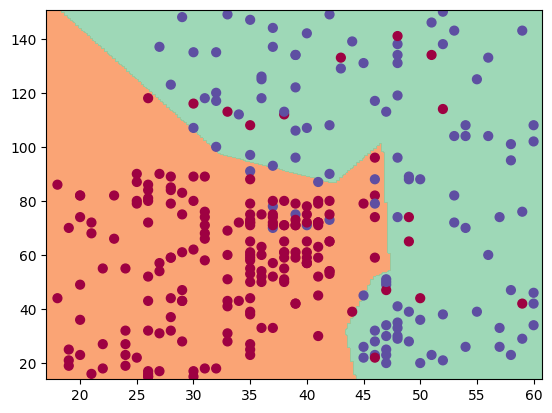

In [ ]:
h = 0.25
x_min, x_max = X_set[:, 0].min() - 1, X_set[:, 0].max() + 1
y_min, y_max = X_set[:, 1].min() - 1, X_set[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Xmesh = np.c_[xx.ravel(), yy.ravel()]
Xmesh = sc.transform(Xmesh)
inputs = [list(map(Value, xrow)) for xrow in Xmesh]
scores = list(map(mlp, inputs))
Z = np.array([s.data >= 0.5 for s in scores])
Z = Z.reshape(xx.shape)

fig = plt.figure()
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
plt.scatter(X_set[:, 0], X_set[:, 1], c=y_train, s=40, cmap=plt.cm.Spectral)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())

---
## dl06_pytorch.ipynb
---


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
dataset = pd.read_csv('Age_Salary_Buy.csv')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values
print(dataset.iloc[:10, :])
X[:,1] = X[:,1]/1000
print(X[:10,:])

   Age  EstimatedSalary  Purchased
0   19            19000          0
1   35            20000          0
2   26            43000          0
3   27            57000          0
4   19            76000          0
5   27            58000          0
6   27            84000          0
7   32           150000          1
8   25            33000          0
9   35            65000          0
[[ 19  19]
 [ 35  20]
 [ 26  43]
 [ 27  57]
 [ 19  76]
 [ 27  58]
 [ 27  84]
 [ 32 150]
 [ 25  33]
 [ 35  65]]


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

In [ ]:
# Keep copies for plotting
X_train_orig = X_train.copy()
X_test_orig  = X_test.copy()

In [ ]:
print(X_train_orig[:10,:])

[[ 44  39]
 [ 32 120]
 [ 38  50]
 [ 32 135]
 [ 52  21]
 [ 53 104]
 [ 39  42]
 [ 38  61]
 [ 36  50]
 [ 36  63]]


In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

# Compute the means and standard deviations of features w.r.t
# training set. Transform X_train
X_train = sc.fit_transform(X_train)

# Using the scaler computed above, transform X_test
X_test = sc.transform(X_test)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
# model: 2 -> 4 -> 1, ReLU + Sigmoid
model = nn.Sequential(
    nn.Linear(2, 4),
    nn.ReLU(),
    nn.Linear(4, 1),
    nn.Sigmoid()
)


X = torch.from_numpy(X_train).float()
y = torch.from_numpy(y_train).float()

loss_fn = nn.BCELoss()
opt = optim.SGD(model.parameters(), lr=0.05, momentum=0.9)

batch_size = 32
N = X.size(0)

for epoch in range(500):
    perm = torch.randperm(N)          # shuffle (like np.random.permutation)
    Xs, ys = X[perm], y[perm]

    for i in range(0, N, batch_size):
        xb = Xs[i:i+batch_size]
        yb = ys[i:i+batch_size]

        y_pred = model(xb)
        yb = yb.unsqueeze(1)
        loss = loss_fn(y_pred, yb)

        opt.zero_grad()
        loss.backward()
        opt.step()

In [ ]:
def predict_proba(model, X):
    model.eval()
    with torch.no_grad():
        return model(X).squeeze().numpy()

def predict(model, X, threshold=0.5):
    probs = predict_proba(model, X)
    return (probs >= threshold).astype(int)

In [ ]:
y_pred = predict(model, X)

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_train, y_pred)
print(cm)
print(accuracy_score(y_train, y_pred))

[[175  14]
 [ 10 101]]
0.92


In [ ]:
y_pred_test = predict(model, torch.from_numpy(X_test).float())

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred_test)
print(cm)
print(accuracy_score(y_test, y_pred_test))

[[64  4]
 [ 3 29]]
0.93


---
## torch01.ipynb
---


# PyTorch 

In [ ]:
# install torch
# pip install torch==2.4.1 (cmd)

In [ ]:
import torch
torch.__version__

'2.11.0+cpu'

## Understanding tensors

Tensors represent a mathematical concept that generalizes vectors and matrices to potentially higher dimensions. In other words, tensors are mathematical objects that can be characterized by their order (or rank), which provides the number of dimensions. For example, a scalar (just a number) is a tensor of rank 0, a vector is a tensor of rank 1, and a matrix is a tensor of rank 2.

From a computational perspective, tensors serve as data containers. For instance, they hold multi-dimensional data, where each dimension represents a different feature. Tensor libraries, such as PyTorch, can create, manipulate, and compute with these multi-dimensional arrays efficiently. In this context, a tensor library functions as an array library.

In [ ]:
# create a 0D tensor (scalar) from a Python integer
tensor0d = torch.tensor(1)

# create a 1D tensor (vector) from a Python list
tensor1d = torch.tensor([1, 2, 3])

# create a 2D tensor from a nested Python list
tensor2d = torch.tensor([[1, 2], [3, 4]])

# create a 3D tensor from a nested Python list
tensor3d = torch.tensor([[[1, 2], [3, 4]], [[5, 6], [7, 8]]])

## Tensor data types

PyTorch adopts the default 64-bit integer data type from Python. We can access the data type of a tensor via the .dtype attribute of a tensor:

In [ ]:
tensor1d = torch.tensor([1, 2, 3])
print(tensor1d.dtype)

torch.int64


If we create tensors from Python floats, PyTorch creates tensors with a 32-bit precision by default, as we can see below:

In [ ]:
floatvec = torch.tensor([1.0, 2.0, 3.0])
print(floatvec.dtype)

torch.float32


## Common PyTorch tensor operations

In [ ]:
tensor2d = torch.tensor([[1, 2, 3], 
                         [4, 5, 6]])
print(tensor2d.shape)

torch.Size([2, 3])


To reshape the tensor into a 3 by 2 tensor, we can use the .reshape method (or .view):

In [ ]:
tensor2d.reshape(3, 2)

tensor([[1, 2],
        [3, 4],
        [5, 6]])

In [ ]:
tensor2d.view(3, 2)

tensor([[1, 2],
        [3, 4],
        [5, 6]])

We can use .T to transpose a tensor, which means flipping it across its diagonal. Note that this is different from reshaping a tensor as you can see based on the result below

In [ ]:
tensor2d.T

tensor([[1, 4],
        [2, 5],
        [3, 6]])

The common way to multiply two matrices in PyTorch is the .matmul method (or use the @ operator):

In [ ]:
tensor2d.matmul(tensor2d.T)

tensor([[14, 32],
        [32, 77]])

## Models as computation graphs

In [ ]:
import torch.nn.functional as F

y = torch.tensor([1.0])  # true label
x1 = torch.tensor([1.1]) # input feature
w1 = torch.tensor([2.2]) # weight parameter
b = torch.tensor([0.0])  # bias unit

z = x1 * w1 + b          # net input
a = torch.sigmoid(z)     # activation & output

loss = F.binary_cross_entropy(a, y)
print(loss)

tensor(0.0852)


## Automatic differentiation

In [ ]:
import torch.nn.functional as F
from torch.autograd import grad

y = torch.tensor([1.0])
x1 = torch.tensor([1.1])
w1 = torch.tensor([2.2], requires_grad=True)
b = torch.tensor([0.0], requires_grad=True)

z = x1 * w1 + b
a = torch.sigmoid(z)

loss = F.binary_cross_entropy(a, y)

grad_L_w1 = grad(loss, w1, retain_graph=True)
grad_L_b = grad(loss, b, retain_graph=True)

By default, PyTorch destroys the computation graph after calculating the gradients to free memory. However, since we are going to reuse this computation graph shortly, we set retain_graph=True so that it stays in memory.

In [ ]:
print(grad_L_w1)
print(grad_L_b)

(tensor([-0.0898]),)
(tensor([-0.0817]),)


Above, we have been using the grad function “manually,” which can be useful for experimentation, debugging, and demonstrating concepts. But in practice, PyTorch provides even more high-level tools to automate this process. For instance, we can call .backward on the loss, and PyTorch will compute the gradients of all the leaf nodes in the graph, which will be stored via the tensors’ .grad attributes:

In [ ]:
loss.backward()

print(w1.grad)
print(b.grad)

tensor([-0.0898])
tensor([-0.0817])


## Implementing multilayer neural networks

When implementing a neural network in PyTorch, we typically subclass the torch.nn.Module class to define our own custom network architecture. This Module base class provides a lot of functionality, making it easier to build and train models. For instance, it allows us to encapsulate layers and operations and keep track of the model’s parameters.

Within this subclass, we define the network layers in the __init__ constructor and specify how they interact in the forward method. The forward method describes how the input data passes through the network and comes together as a computation graph.

In contrast, the backward method, which we typically do not need to implement ourselves, is used during training to compute gradients of the loss function with respect to the model parameters

The following code implements a classic multilayer perceptron with two hidden layers to illustrate a typical usage of the Module class:

In [ ]:
class NeuralNetwork(torch.nn.Module): # subclassing Module
    def __init__(self, num_inputs, num_outputs):
        super().__init__()

        self.layers = torch.nn.Sequential(

            # 1st hidden layer
            torch.nn.Linear(num_inputs, 30),
            torch.nn.ReLU(),

            # 2nd hidden layer
            torch.nn.Linear(30, 20),
            torch.nn.ReLU(),

            # output layer
            torch.nn.Linear(20, num_outputs),
        )

    def forward(self, x):
        logits = self.layers(x)
        return logits

We can then instantiate a new neural network object as follows:

In [ ]:
model = NeuralNetwork(50, 3)

In [ ]:
print(model)

NeuralNetwork(
  (layers): Sequential(
    (0): Linear(in_features=50, out_features=30, bias=True)
    (1): ReLU()
    (2): Linear(in_features=30, out_features=20, bias=True)
    (3): ReLU()
    (4): Linear(in_features=20, out_features=3, bias=True)
  )
)


Next, let’s check the total number of trainable parameters of this model:

In [ ]:
num_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad
)
print("Total number of trainable model parameters:", num_params)

Total number of trainable model parameters: 2213


In [ ]:
print(model.layers[0].weight.shape)

torch.Size([30, 50])


The forward pass:

In [ ]:
torch.manual_seed(123)

X = torch.rand((1, 50))
out = model(X)
print(out)

tensor([[ 0.0230,  0.1286, -0.0503]], grad_fn=<AddmmBackward0>)


## Using model for prediction after training

In [ ]:
with torch.no_grad():
    out = model(X)
print(out)

tensor([[ 0.0230,  0.1286, -0.0503]])


In PyTorch, it’s common practice to code models such that they return the outputs of the last layer (logits) without passing them to a nonlinear activation function. That’s because PyTorch’s commonly used loss functions combine the softmax (or sigmoid for binary classification) operation with the negative log-likelihood loss in a single class. The reason for this is numerical efficiency and stability. So, if we want to compute class-membership probabilities for our predictions, we have to call the softmax function explicitly:

In [ ]:
with torch.no_grad():
    out = torch.softmax(model(X), dim=1) # or sigmoid for binary classification
print(out)

tensor([[0.3289, 0.3655, 0.3056]])
